In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kidney-disease.zip.zip to kidney-disease.zip (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile('kidney-disease.zip.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

In [ ]:
import os

print(os.listdir('dataset'))

['Chronic_Kidney_Disease.rar']


In [ ]:
import pandas as pd
from scipy.io import arff
import tempfile
import os

# The error 'ValueError: no value not in ('ckd', 'notckd')' indicates that for the 'class'
# attribute, which is defined with 'ckd'/'notckd' values, the data contains 'no'.
# We need to preprocess the ARFF file to map 'no' to 'notckd' for such attributes.

arff_file_path = '/content/chronic_kidney_disease.arff'
cleaned_lines = []
data_section = False
attributes_metadata = [] # To store (attribute_name, {allowed_values} or None for numeric)

with open(arff_file_path, 'r') as f:
    for line in f:
        stripped_line = line.strip()
        if not data_section:
            cleaned_lines.append(line) # Keep header lines as is

            if stripped_line.upper().startswith('@ATTRIBUTE'):
                # Parse attribute definitions from the header
                parts = stripped_line.split()
                attr_name = parts[1].strip("'")
                if '{' in stripped_line and '}' in stripped_line:
                    # Categorical attribute: extract allowed values
                    values_str = stripped_line[stripped_line.find('{')+1:stripped_line.find('}')]
                    allowed_values = {v.strip() for v in values_str.split(',')}
                    attributes_metadata.append((attr_name, allowed_values))
                else:
                    # Numeric or other type: no specific allowed values list
                    attributes_metadata.append((attr_name, None))

            if stripped_line.upper() == '@DATA':
                data_section = True
        else:
            if stripped_line: # Avoid processing truly empty lines (e.g., just newline)
                values = []
                raw_values_for_line = stripped_line.split(',')
                for i, v_raw in enumerate(raw_values_for_line):
                    stripped_v = v_raw.strip()

                    # Apply specific mappings for known inconsistencies
                    if i < len(attributes_metadata):
                        _attr_name, allowed_vals = attributes_metadata[i]
                        if allowed_vals is not None:
                            if 'good' in allowed_vals and 'poor' in allowed_vals: # For 'appetite'
                                if stripped_v == 'no':
                                    stripped_v = 'poor'
                            elif 'yes' in allowed_vals and 'no' in allowed_vals: # For binary 'yes'/'no' attributes
                                if stripped_v == 'good':
                                    stripped_v = 'yes'
                                elif stripped_v == 'bad':
                                    stripped_v = 'no'
                            elif 'ckd' in allowed_vals and 'notckd' in allowed_vals: # For 'class' attribute
                                if stripped_v == 'no':
                                    stripped_v = 'notckd'

                    # General handling for empty strings (after stripping) as missing values
                    if stripped_v == '':
                        stripped_v = '?'

                    values.append(stripped_v)
                cleaned_lines.append(','.join(values) + '\n')
            else:
                cleaned_lines.append(line)

# Write the cleaned content to a temporary ARFF file
with tempfile.NamedTemporaryFile(mode='w', suffix='.arff', delete=False) as temp_arff_file:
    temp_arff_file.writelines(cleaned_lines)
    temp_arff_path = temp_arff_file.name

# Load the cleaned ARFF file using scipy.io.arff.loadarff
data, meta = arff.loadarff(temp_arff_path)
df = pd.DataFrame(data)

# Decode byte strings to regular strings for object columns, common with arff.loadarff
for column in df.select_dtypes(['object']).columns:
    df[column] = df[column].str.decode('utf-8')

# Clean up the temporary file
os.remove(temp_arff_path)

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1,0,?,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4,0,?,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2,3,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4,0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2,0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [ ]:
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

    age    bp     sg al su     rbc        pc         pcc          ba    bgr  \
0  48.0  80.0  1.020  1  0       ?    normal  notpresent  notpresent  121.0   
1   7.0  50.0  1.020  4  0       ?    normal  notpresent  notpresent    NaN   
2  62.0  80.0  1.010  2  3  normal    normal  notpresent  notpresent  423.0   
3  48.0  70.0  1.005  4  0  normal  abnormal     present  notpresent  117.0   
4  51.0  80.0  1.010  2  0  normal    normal  notpresent  notpresent  106.0   

   ...   pcv    wbcc  rbcc  htn   dm  cad  appet   pe  ane class  
0  ...  44.0  7800.0   5.2  yes  yes   no   good   no   no   ckd  
1  ...  38.0  6000.0   NaN   no   no   no   good   no   no   ckd  
2  ...  31.0  7500.0   NaN   no  yes   no   poor   no  yes   ckd  
3  ...  32.0  6700.0   3.9  yes   no   no   poor  yes  yes   ckd  
4  ...  35.0  7300.0   4.6   no   no   no   good   no   no   ckd  

[5 rows x 25 columns]

Dataset Shape:
(400, 25)

Columns:
Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 

In [ ]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'class'],
      dtype='object')


In [ ]:
features = [
    'age',
    'bp',
    'bgr',
    'bu',
    'sod',
    'pot',
    'hemo',
    'pcv',
    'wbcc',  # Corrected from 'wc'
    'rbcc'   # Corrected from 'rc'
]

target = 'sc'   # Serum Creatinine

X = df[features]
y = df[target]

In [ ]:
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

In [ ]:
imputer = SimpleImputer(strategy='mean')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

y = y.fillna(y.mean())

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (320, 10)
Testing Samples: (80, 10)


In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Complete")

Model Training Complete


In [ ]:
predictions = model.predict(X_test)

print(predictions[:10])

[3.12086162 0.8875     2.7115359  7.87175    6.20025    9.74575
 1.4775     2.67812272 1.39022454 5.0245    ]


In [ ]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 1.5329563152741508
MSE : 29.76165801672268
RMSE: 5.455424641283452
R² Score: 0.24202221953632785


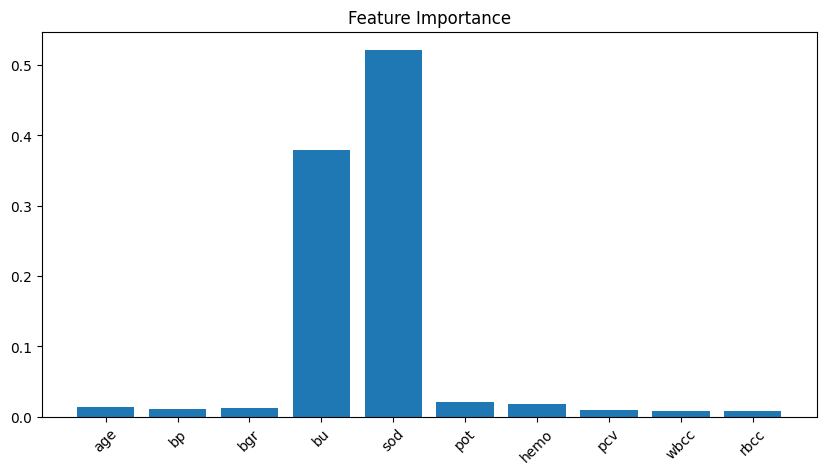

In [ ]:
importance = model.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(X.columns, importance)

plt.title("Feature Importance")
plt.xticks(rotation=45)

plt.show()

In [ ]:
joblib.dump(model, "creatinine_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
from google.colab import files

files.download("creatinine_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
new_patient = pd.DataFrame({
    'age':[55],
    'bp':[140],
    'bgr':[150],
    'bu':[60],
    'sod':[135],
    'pot':[4.5],
    'hemo':[11],
    'pcv':[35],
    'wbcc':[9000], # Corrected from 'wc'
    'rbcc':[4.2]  # Corrected from 'rc'
})

prediction = model.predict(new_patient)

print("Predicted Creatinine Level:", prediction[0])

Predicted Creatinine Level: 2.5931586161879894


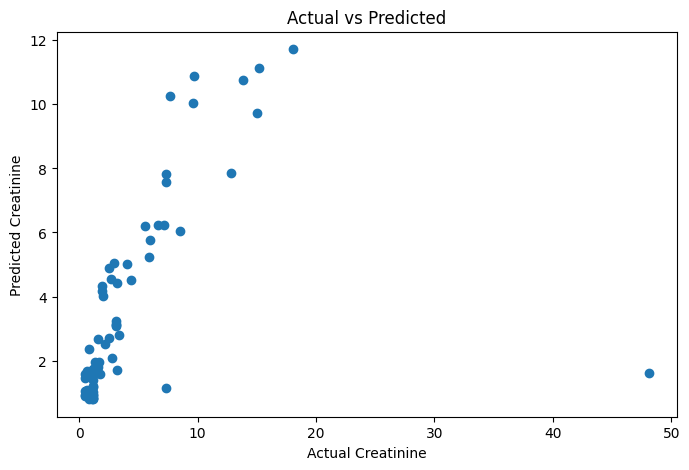

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Creatinine")
plt.ylabel("Predicted Creatinine")

plt.title("Actual vs Predicted")

plt.show()

In [ ]:
new_patient = pd.DataFrame({
    'age':[55],
    'bp':[140],
    'bgr':[150],
    'bu':[60],
    'sod':[135],
    'pot':[4.5],
    'hemo':[11],
    'pcv':[35],
    'wbcc':[9000],
    'rbcc':[4.2]
})

prediction = model.predict(new_patient)

creatinine_level = prediction[0]

print("Predicted Creatinine Level:", round(creatinine_level, 2), "mg/dL")

if creatinine_level < 1.2:
    risk = "Normal"
elif creatinine_level <= 1.5:
    risk = "Mild Risk"
else:
    risk = "High Risk"

print("Risk Status:", risk)

Predicted Creatinine Level: 2.59 mg/dL
Risk Status: High Risk


for the risk indication when the creatinine is above 1.5


In [ ]:
if creatinine_level < 1.2:
    print("Recommendation: Kidney function appears normal.")

elif creatinine_level <= 1.5:
    print("Recommendation: Monitor kidney function and maintain hydration.")

else:
    print("⚠ High Risk: Consult a nephrologist and undergo further kidney evaluation.")

⚠ High Risk: Consult a nephrologist and undergo further kidney evaluation.


for Health Recommendation

In [ ]:
new_patient = pd.DataFrame({
    'age':[55],
    'bp':[140],
    'bgr':[150],
    'bu':[60],
    'sod':[135],
    'pot':[4.5],
    'hemo':[11],
    'pcv':[35],
    'wbcc':[9000], # Corrected from 'wc'
    'rbcc':[4.2]  # Corrected from 'rc'
})

prediction = model.predict(new_patient)[0]

print(f"Predicted Creatinine Level: {prediction:.2f} mg/dL")

# Alert System
if prediction > 1.5:
    print("\n🚨 HIGH RISK ALERT 🚨")
    print("Creatinine level is above 1.5 mg/dL.")
    print("Possible kidney function impairment detected.")
    print("Immediate medical evaluation is recommended.")
else:
    print("\n✅ Creatinine level is within the acceptable range.")

Predicted Creatinine Level: 2.59 mg/dL

🚨 HIGH RISK ALERT 🚨
Creatinine level is above 1.5 mg/dL.
Possible kidney function impairment detected.
Immediate medical evaluation is recommended.


Alert system

In [ ]:
from IPython.display import HTML, display

if prediction > 1.5:
    display(HTML("""
    <div style="padding:15px;
                background-color:#ffcccc;
                border:2px solid red;
                border-radius:10px;">
        <h2>🚨 HIGH RISK ALERT 🚨</h2>
        <p>Predicted Creatinine Level exceeds 1.5 mg/dL.</p>
        <p>Medical consultation is recommended.</p>
    </div>
    """))
else:
    display(HTML("""
    <div style="padding:15px;
                background-color:#ccffcc;
                border:2px solid green;
                border-radius:10px;">
        <h2>✅ NORMAL</h2>
        <p>Predicted Creatinine Level is within the acceptable range.</p>
    </div>
    """))

color alert


In [ ]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

results["Risk"] = results["Predicted"].apply(
    lambda x: "High Risk Alert" if x > 1.5 else "Normal"
)

results.head()

,Actual,Predicted,Risk
209,3.072454,3.120862,High Risk Alert
280,0.900000,0.887500,Normal
33,2.500000,2.711536,High Risk Alert
210,12.800000,7.871750,High Risk Alert
93,5.600000,6.200250,High Risk Alert


In [ ]:
print(model)

RandomForestRegressor(n_estimators=200, random_state=42)


In [ ]:
print(model.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [ ]:
import joblib

joblib.dump(model, "creatinine_model.pkl")

['creatinine_model.pkl']

In [ ]:
loaded_model = joblib.load("creatinine_model.pkl")

print(loaded_model)

RandomForestRegressor(n_estimators=200, random_state=42)


In [ ]:
print("MODEL SUMMARY")
print("="*40)

print("Algorithm:", type(model).__name__)
print("Features:", list(X.columns))
print("Number of Features:", len(X.columns))
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Number of Trees:", len(model.estimators_))

MODEL SUMMARY
Algorithm: RandomForestRegressor
Features: ['age', 'bp', 'bgr', 'bu', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
Number of Features: 10
Training Samples: 320
Testing Samples: 80
Number of Trees: 200
